# NBA Players stats(2023 season)
### 2022-2023的 82 場例行賽
[點我看網站](https://www.kaggle.com/datasets/amirhosseinmirzaie/nba-players-stats2023-season)

## Position與進攻、防守的關係
- 

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

In [62]:
data = pd.read_csv('2023nbasalary.csv')

In [63]:
data.head()

,PName,POS,Team,Age,GP,W,L,Min,PTS,FGM,...,APG,TOPG,SPG,BPG,FPG,TS%,AT,Avg_PM,Avg_FP,Salary
0,Jayson Tatum,SF,BOS,25,74,52,22,2732.2,2225,727,...,4.621622,2.878378,1.054054,0.689189,2.162162,60.703451,1.605634,6.351351,49.878378,32600060.0
1,Joel Embiid,C,PHI,29,66,43,23,2284.1,2183,728,...,4.151515,3.424242,1.000000,1.696970,3.106061,65.467479,1.212389,6.424242,56.151515,53320232.0
2,Luka Doncic,PG,DAL,24,66,33,33,2390.5,2138,719,...,8.015152,3.575758,1.363636,0.500000,2.515152,60.933902,2.241525,1.939394,56.772727,43031940.0
3,Shai Gilgeous-Alexander,PG,OKC,24,68,33,35,2416.0,2135,704,...,5.455882,2.823529,1.647059,0.955882,2.823529,62.567403,1.932292,2.191176,50.367647,35859950.0
4,Giannis Antetokounmpo,PF,MIL,28,63,47,16,2023.6,1959,707,...,5.698413,3.904762,0.825397,0.809524,3.126984,60.549676,1.459350,5.412698,54.777778,45640084.0


| G | SG | PG | F | SF | PF | C |
|----|---|----|----|----|---|---|
| Guard | Shooting_Guard | Point_Guard | Forward | Small_Forward | Power_Forward | Center |
| 後衛 | 得分後衛 | 控球後衛 | 前鋒 | 小前鋒 | 大前鋒 | 中鋒 |

In [64]:
data.rename(columns={
    'PName': 'Player_Name',
    'POS': 'Position',
    'Team': 'Team_Abbreviation',
    'Age': 'Age',
    'GP': 'Games_Played',
    'W': 'Wins',
    'L': 'Losses',
    'Min': 'Minutes_Played',
    'PTS': 'Total_Points',
    'FGM': 'Field_Goal_Made',
    'FGA': 'Field_Goal_Attempted',
    'FG%': 'Field_Goal_Percentage',
    '3PM': 'Three_Point_Made',
    '3PA': 'Three_Point_Attempted',
    '3P%': 'Three_Point_Percentage',
    'FTM': 'Free_Throw_Made',
    'FTA': 'Free_Throw_Attempted',
    'FT%': 'Free_Throw_Percentage',
    'OREB': 'Offensive_Rebounds',
    'DREB': 'Defensive_Rebounds',
    'REB': 'Total_Rebounds',
    'AST': 'Assists',
    'TOV': 'Turnovers',
    'STL': 'Steals',
    'BLK': 'Blocks',
    'PF': 'Personal_Fouls',
    'FP': 'NBA_Fantasy_Points',
    'DD2': 'Double_Doubles',
    'TD3': 'Triple_Doubles',
    '+/-': 'Plus_Minus',
    'PPG': 'Points_Per_Game',
    'RPG': 'Rebounds_Per_Game',
    'APG' :'Assists_Per_Game',
    'TOPG' :'Turnovers_Per_Game',
    'SPG' :'Steals_Per_Game',
    'BPG' :'Blocks_Per_Game',
    'FPG' :'Fouls_Per_Game',
    'TS%' :'True_Shooting_Percentage'
}, inplace=True)

## 欄位說明
[參考](https://www.basketball-reference.com/about/glossary.html#fg)

| 原始欄位 | 英文說明欄位 | 中文解釋 |
|---------|--------------|----------|
| PName   | Player_Name | 球員姓名 |
| POS     | Position | 場上位置 |
| Team    | Team_Abbreviation | 球隊縮寫 |
| Age     | Age | 年齡 |
| GP      | Games_Played | 出賽場次 |
| W       | Wins | 勝場 |
| L       | Losses | 敗場 |
| Min     | Minutes_Played | 上場時間（分鐘） |
| PTS     | Total_Points | 總得分 |
| FGM     | Field_Goal_Made | 投籃命中數 |
| FGA     | Field_Goal_Attempted | 投籃出手數 |
| FG%     | Field_Goal_Percentage | 投籃命中率 |
| 3PM     | Three_Point_Made | 三分命中數 |
| 3PA     | Three_Point_Attempted | 三分出手數 |
| 3P%     | Three_Point_Percentage | 三分命中率 |
| FTM     | Free_Throw_Made | 罰球命中數 |
| FTA     | Free_Throw_Attempted | 罰球出手數 |
| FT%     | Free_Throw_Percentage | 罰球命中率 |
| OREB    | Offensive_Rebounds | 進攻籃板 |
| DREB    | Defensive_Rebounds | 防守籃板 |
| REB     | Total_Rebounds | 總籃板 |
| AST     | Assists | 助攻 |
| TOV     | Turnovers | 失誤 |
| STL     | Steals | 抄截 |
| BLK     | Blocks | 阻攻（火鍋） |
| PF      | Personal_Fouls | 犯規 |
| FP      | NBA_Fantasy_Points | NBA Fantasy 積分 |
| DD2     | Double_Doubles | 「雙十」次數 |
| TD3     | Triple_Doubles | 「大三元」次數 |
| +/-     | Plus_Minus | 場上正負值 |
| PPG     | Points Per Game | 場均得分 |
| RPG     | Rebounds Per Game | 場均籃板 |
| APG     | Assists Per Game | 場均助攻 |
| TOPG    | Turnovers Per Game | 場均失誤 |
| SPG     | Steals Per Game | 場均抄截 |
| BPG     | Blocks Per Game | 場均蓋冒 | 
| FPG     | Fouls Per Game | 場均犯規 |
| TS%     | True Shooting Percentage | 真實命中率 | 

### How to calculate the fantasy points
- Three Point Field Goals: 3 points
- Two Point Field Goals: 2 points
- Free Throws Made: 1 point
- Rebounds: 1.2 points
- Assists: 1.5 points
- Blocked Shots: 2 points
- Steals: 2 points
- Turnovers: -1 points


In [65]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 539 entries, 0 to 538
Data columns (total 42 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Player_Name               539 non-null    object 
 1   Position                  539 non-null    object 
 2   Team_Abbreviation         539 non-null    object 
 3   Age                       539 non-null    int64  
 4   Games_Played              539 non-null    int64  
 5   Wins                      539 non-null    int64  
 6   Losses                    539 non-null    int64  
 7   Minutes_Played            539 non-null    float64
 8   Total_Points              539 non-null    int64  
 9   Field_Goal_Made           539 non-null    int64  
 10  Field_Goal_Attempted      539 non-null    int64  
 11  Field_Goal_Percentage     539 non-null    float64
 12  Three_Point_Made          539 non-null    int64  
 13  Three_Point_Attempted     539 non-null    int64  
 14  Three_Poin

In [66]:
data['Salary'] = data['Salary'].fillna((data['Salary']).median())

In [67]:
data.duplicated().sum()

0

In [68]:
data.isna().sum()

Player_Name                  0
Position                     0
Team_Abbreviation            0
Age                          0
Games_Played                 0
Wins                         0
Losses                       0
Minutes_Played               0
Total_Points                 0
Field_Goal_Made              0
Field_Goal_Attempted         0
Field_Goal_Percentage        0
Three_Point_Made             0
Three_Point_Attempted        0
Three_Point_Percentage       0
Free_Throw_Made              0
Free_Throw_Attempted         0
Free_Throw_Percentage        0
Offensive_Rebounds           0
Defensive_Rebounds           0
Total_Rebounds               0
Assists                      0
Turnovers                    0
Steals                       0
Blocks                       0
Personal_Fouls               0
NBA_Fantasy_Points           0
Double_Doubles               0
Triple_Doubles               0
Plus/Minus                   0
Points_Per_Game              0
Rebounds_Per_Game            0
Assists_

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Player_Name</th>
      <th>Position</th>
      <th>Team_Abbreviation</th>
      <th>Age</th>
      <th>Games_Played</th>
      <th>Wins</th>
      <th>Losses</th>
      <th>Minutes_Played</th>
      <th>Total_Points</th>
      <th>Field_Goal_Made</th>
      <th>...</th>
      <th>Three_Point_Made_Per_Game</th>
      <th>Three_Point_Attempted_Per_Game</th>
      <th>Three_Point_Attempted_Rate</th>
      <th>Free_Throw_Attempted_Per_Game</th>
      <th>Minutes_Played_Per_Game</th>
      <th>Assists/Turnover_Percentage</th>
      <th>Usage_Percentage</th>
      <th>Effective_Field_Goal_Percentage</th>
      <th>Assists_Percentage</th>
      <th>Turnovers_Percentage</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>Jayson Tatum</td>
      <td>SF</td>
      <td>BOS</td>
      <td>25</td>
      <td>74</td>
      <td>52</td>
      <td>22</td>
      <td>2732.2</td>
      <td>2225</td>
      <td>727</td>
      <td>...</td>
      <td>3.243243</td>
      <td>9.270270</td>
      <td>44.002566</td>
      <td>8.405405</td>
      <td>36.921622</td>
      <td>160.563380</td>
      <td>33.060489</td>
      <td>54.329699</td>
      <td>21.019590</td>
      <td>10.412186</td>
    </tr>
    <tr>
      <th>1</th>
      <td>Joel Embiid</td>
      <td>C</td>
      <td>PHI</td>
      <td>29</td>
      <td>66</td>
      <td>43</td>
      <td>23</td>
      <td>2284.1</td>
      <td>2183</td>
      <td>728</td>
      <td>...</td>
      <td>1.000000</td>
      <td>3.030303</td>
      <td>15.060241</td>
      <td>11.681818</td>
      <td>34.607576</td>
      <td>121.238938</td>
      <td>36.939470</td>
      <td>57.304217</td>
      <td>22.687995</td>
      <td>11.937208</td>
    </tr>
    <tr>
      <th>2</th>
      <td>Luka Doncic</td>
      <td>PG</td>
      <td>DAL</td>
      <td>24</td>
      <td>66</td>
      <td>33</td>
      <td>33</td>
      <td>2390.5</td>
      <td>2138</td>
      <td>719</td>
      <td>...</td>
      <td>2.803030</td>
      <td>8.196970</td>
      <td>37.336094</td>
      <td>10.515152</td>
      <td>36.219697</td>
      <td>224.152542</td>
      <td>36.139285</td>
      <td>56.004141</td>
      <td>38.693547</td>
      <td>11.857151</td>
    </tr>
    <tr>
      <th>3</th>
      <td>Shai Gilgeous-Alexander</td>
      <td>PG</td>
      <td>OKC</td>
      <td>24</td>
      <td>68</td>
      <td>33</td>
      <td>35</td>
      <td>2416.0</td>
      <td>2135</td>
      <td>704</td>
      <td>...</td>
      <td>0.852941</td>
      <td>2.470588</td>
      <td>12.165098</td>
      <td>10.867647</td>
      <td>35.529412</td>
      <td>193.229167</td>
      <td>32.573588</td>
      <td>53.077480</td>
      <td>25.273725</td>
      <td>10.115059</td>
    </tr>
    <tr>
      <th>4</th>
      <td>Giannis Antetokounmpo</td>
      <td>PF</td>
      <td>MIL</td>
      <td>28</td>
      <td>63</td>
      <td>47</td>
      <td>16</td>
      <td>2023.6</td>
      <td>1959</td>
      <td>707</td>
      <td>...</td>
      <td>0.746032</td>
      <td>2.714286</td>
      <td>13.380282</td>
      <td>12.253968</td>
      <td>32.120635</td>
      <td>145.934959</td>
      <td>38.208234</td>
      <td>57.159624</td>
      <td>31.730435</td>
      <td>13.199691</td>
    </tr>
  </tbody>
</table>
<p>5 rows × 65 columns</p>
</div>

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>Player_Name</th>
      <th>Position</th>
      <th>Team_Abbreviation</th>
      <th>Age</th>
      <th>Games_Played</th>
      <th>Wins</th>
      <th>Losses</th>
      <th>Minutes_Played</th>
      <th>Total_Points</th>
      <th>Field_Goal_Made</th>
      <th>...</th>
      <th>Three_Point_Made_Per_Game</th>
      <th>Three_Point_Attempted_Per_Game</th>
      <th>Three_Point_Attempted_Rate</th>
      <th>Free_Throw_Attempted_Per_Game</th>
      <th>Minutes_Played_Per_Game</th>
      <th>Assists/Turnover_Percentage</th>
      <th>Usage_Percentage</th>
      <th>Effective_Field_Goal_Percentage</th>
      <th>Assists_Percentage</th>
      <th>Turnovers_Percentage</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>Jayson Tatum</td>
      <td>SF</td>
      <td>BOS</td>
      <td>25</td>
      <td>74</td>
      <td>52</td>
      <td>22</td>
      <td>2732.2</td>
      <td>2225</td>
      <td>727</td>
      <td>...</td>
      <td>3.243243</td>
      <td>9.270270</td>
      <td>44.002566</td>
      <td>8.405405</td>
      <td>36.921622</td>
      <td>160.563380</td>
      <td>33.060489</td>
      <td>54.329699</td>
      <td>21.019590</td>
      <td>10.412186</td>
    </tr>
    <tr>
      <th>1</th>
      <td>Joel Embiid</td>
      <td>C</td>
      <td>PHI</td>
      <td>29</td>
      <td>66</td>
      <td>43</td>
      <td>23</td>
      <td>2284.1</td>
      <td>2183</td>
      <td>728</td>
      <td>...</td>
      <td>1.000000</td>
      <td>3.030303</td>
      <td>15.060241</td>
      <td>11.681818</td>
      <td>34.607576</td>
      <td>121.238938</td>
      <td>36.939470</td>
      <td>57.304217</td>
      <td>22.687995</td>
      <td>11.937208</td>
    </tr>
    <tr>
      <th>2</th>
      <td>Luka Doncic</td>
      <td>PG</td>
      <td>DAL</td>
      <td>24</td>
      <td>66</td>
      <td>33</td>
      <td>33</td>
      <td>2390.5</td>
      <td>2138</td>
      <td>719</td>
      <td>...</td>
      <td>2.803030</td>
      <td>8.196970</td>
      <td>37.336094</td>
      <td>10.515152</td>
      <td>36.219697</td>
      <td>224.152542</td>
      <td>36.139285</td>
      <td>56.004141</td>
      <td>38.693547</td>
      <td>11.857151</td>
    </tr>
    <tr>
      <th>3</th>
      <td>Shai Gilgeous-Alexander</td>
      <td>PG</td>
      <td>OKC</td>
      <td>24</td>
      <td>68</td>
      <td>33</td>
      <td>35</td>
      <td>2416.0</td>
      <td>2135</td>
      <td>704</td>
      <td>...</td>
      <td>0.852941</td>
      <td>2.470588</td>
      <td>12.165098</td>
      <td>10.867647</td>
      <td>35.529412</td>
      <td>193.229167</td>
      <td>32.573588</td>
      <td>53.077480</td>
      <td>25.273725</td>
      <td>10.115059</td>
    </tr>
    <tr>
      <th>4</th>
      <td>Giannis Antetokounmpo</td>
      <td>PF</td>
      <td>MIL</td>
      <td>28</td>
      <td>63</td>
      <td>47</td>
      <td>16</td>
      <td>2023.6</td>
      <td>1959</td>
      <td>707</td>
      <td>...</td>
      <td>0.746032</td>
      <td>2.714286</td>
      <td>13.380282</td>
      <td>12.253968</td>
      <td>32.120635</td>
      <td>145.934959</td>
      <td>38.208234</td>
      <td>57.159624</td>
      <td>31.730435</td>
      <td>13.199691</td>
    </tr>
  </tbody>
</table>
<p>5 rows × 65 columns</p>
</div>

In [69]:
data.head()

,Player_Name,Position,Team_Abbreviation,Age,Games_Played,Wins,Losses,Minutes_Played,Total_Points,Field_Goal_Made,...,Assists_Per_Game,Turnovers_Per_Game,Steals_Per_Game,Blocks_Per_Game,Fouls_Per_Game,True_Shooting_Percentage,AT,Avg_PM,Avg_FP,Salary
0,Jayson Tatum,SF,BOS,25,74,52,22,2732.2,2225,727,...,4.621622,2.878378,1.054054,0.689189,2.162162,60.703451,1.605634,6.351351,49.878378,32600060.0
1,Joel Embiid,C,PHI,29,66,43,23,2284.1,2183,728,...,4.151515,3.424242,1.000000,1.696970,3.106061,65.467479,1.212389,6.424242,56.151515,53320232.0
2,Luka Doncic,PG,DAL,24,66,33,33,2390.5,2138,719,...,8.015152,3.575758,1.363636,0.500000,2.515152,60.933902,2.241525,1.939394,56.772727,43031940.0
3,Shai Gilgeous-Alexander,PG,OKC,24,68,33,35,2416.0,2135,704,...,5.455882,2.823529,1.647059,0.955882,2.823529,62.567403,1.932292,2.191176,50.367647,35859950.0
4,Giannis Antetokounmpo,PF,MIL,28,63,47,16,2023.6,1959,707,...,5.698413,3.904762,0.825397,0.809524,3.126984,60.549676,1.459350,5.412698,54.777778,45640084.0


### FieldGoalPerGame

In [70]:
data['Field_Goal_Attempted_Per_Game'] = data['Field_Goal_Attempted']/data['Games_Played'].where(data['Games_Played']>0, 0)

data['Field_Goal_Made_Per_Game'] = data['Field_Goal_Made']/data['Games_Played'].where(data['Games_Played']>0, 0)

### Rebouns

In [71]:
data['Offensive_Rebounds_Per_Game'] = (data['Offensive_Rebounds']/data['Games_Played']).where(data['Games_Played']>0, 0)
data['Offensive_Rebounds_Percentage'] = (data['Offensive_Rebounds']/(data['Offensive_Rebounds']+data['Defensive_Rebounds'])).where(data['Games_Played']>0, 0)

data['Defensive_Rebounds_Per_Game'] = (data['Defensive_Rebounds']/data['Games_Played']).where(data['Games_Played']>0, 0)
data['Defensive_Rebounds_Percentage'] = (data['Defensive_Rebounds']/(data['Offensive_Rebounds']+data['Defensive_Rebounds'])).where(data['Games_Played']>0, 0)


### TeamData

In [72]:
team_data = (data.groupby("Team_Abbreviation").agg(Team_FGA=("Field_Goal_Attempted", "sum"), Team_FTA=("Free_Throw_Attempted", "sum"), 
                                                  Team_TOV=("Turnovers", "sum"), Team_MP =("Minutes_Played", "sum"), Team_FGM=('Field_Goal_Made', 'sum')))
data = data.merge(team_data, on="Team_Abbreviation", how="left")

### TwoPoints

In [73]:
data["Two_Point_Made"] = data["Field_Goal_Made"]-data["Three_Point_Made"]
data['Two_Point_Made_Per_Game'] = data["Two_Point_Made"]/data['Games_Played'].where(data["Games_Played"]>0, 0)

data["Two_Point_Attempted"] = data["Field_Goal_Attempted"]-data["Three_Point_Attempted"]
data['Two_Point_Attempted_Per_Game'] = data["Two_Point_Attempted"]/data['Games_Played'].where(data["Games_Played"]>0, 0)
data['Two_Point_Attempted_Rate'] = (100*data["Two_Point_Attempted"]/data['Field_Goal_Attempted']).where(data["Field_Goal_Attempted"]>0, 0)

data["Two_Point_Percentage"] = (100*data["Two_Point_Made"]/data["Two_Point_Attempted"]).where(data["Two_Point_Attempted"]>0, 0)

### ThreePoints

In [74]:
data['Three_Point_Made_Per_Game'] = data["Three_Point_Made"]/data['Games_Played'].where(data["Games_Played"]>0, 0)

data['Three_Point_Attempted_Per_Game'] = data["Three_Point_Attempted"]/data['Games_Played'].where(data["Games_Played"]>0, 0)

data['Three_Point_Attempted_Rate'] = (100*data["Three_Point_Attempted"]/data['Field_Goal_Attempted']).where(data["Field_Goal_Attempted"]>0, 0)


### FreeThrowPerGame

In [75]:
data['Free_Throw_Attempted_Per_Game'] = data["Free_Throw_Attempted"]/data['Games_Played'].where(data["Games_Played"]>0, 0)

### MinutesPlayedPerGame

In [76]:
data['Minutes_Played_Per_Game'] = data['Minutes_Played'] / data['Games_Played'].where(data["Games_Played"]>0, 0)

### BlocksPerGame

In [77]:
data["Blocks_Per_Game"] = data["Blocks"] / data["Games_Played"]

### TS%

In [78]:
data['True_Shooting_Percentage'] = pd.to_numeric(data['True_Shooting_Percentage'], errors='coerce')
data['True_Shooting_Percentage'] = data['True_Shooting_Percentage'].fillna(0)

### Usage%

In [79]:
son =  ((data['Field_Goal_Attempted']+0.44*data['Free_Throw_Attempted']+data['Turnovers'])*(data['Team_MP']/5))
mom = data["Minutes_Played"]*(data["Team_FGA"]+0.44*data["Team_FTA"]+data["Team_TOV"])
data['Usage_Percentage'] = (100*son/mom).where(mom>0, 0)

### eFG%

In [80]:
data['Effective_Field_Goal_Percentage'] = (100*((data['Field_Goal_Made']+0.5*data['Three_Point_Made'])/data['Field_Goal_Attempted'])).where(data["Field_Goal_Attempted"]>0, 0)

### AST%

In [81]:
mom2 = (((data['Minutes_Played']/(data['Team_MP']/5))*data['Team_FGM']))-data['Field_Goal_Made']
data['Assists_Percentage'] = (100*data['Assists']/mom2).where(mom2>0, 0)

### TOV%

In [82]:
mom3 = data['Field_Goal_Attempted']+0.44*data['Free_Throw_Attempted']+data['Turnovers']
data['Turnovers_Percentage'] = (100*data['Turnovers'])/mom3.where(mom3>0, 0)

---

In [83]:
data.describe()

,Age,Games_Played,Wins,Losses,Minutes_Played,Total_Points,Field_Goal_Made,Field_Goal_Attempted,Field_Goal_Percentage,Three_Point_Made,...,Two_Point_Percentage,Three_Point_Made_Per_Game,Three_Point_Attempted_Per_Game,Three_Point_Attempted_Rate,Free_Throw_Attempted_Per_Game,Minutes_Played_Per_Game,Usage_Percentage,Effective_Field_Goal_Percentage,Assists_Percentage,Turnovers_Percentage
count,539.000000,539.000000,539.000000,539.000000,539.000000,539.000000,539.000000,539.000000,539.000000,539.000000,...,539.000000,539.000000,539.000000,539.000000,539.000000,539.000000,539.000000,539.000000,539.000000,538.000000
mean,25.970315,48.040816,24.018553,24.022263,1103.617625,523.426716,191.576994,403.005566,46.325232,56.324675,...,52.988137,0.990038,2.782890,40.029688,1.855938,19.796567,18.574018,53.187150,13.467328,12.593740
std,4.315513,24.650686,14.496366,13.445866,827.765114,498.084360,178.351286,369.595909,10.967271,60.916821,...,14.029320,0.872909,2.243816,21.981050,1.880296,9.541295,5.825914,10.618800,8.671406,6.922353
min,19.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,23.000000,30.500000,12.000000,14.000000,329.000000,120.500000,45.500000,93.500000,41.650000,5.000000,...,48.532999,0.316986,1.000000,25.993266,0.629123,12.452484,14.394007,49.441898,7.274880,9.448659
50%,25.000000,54.000000,25.000000,25.000000,970.200000,374.000000,138.000000,300.000000,45.500000,36.000000,...,53.592814,0.789474,2.365385,40.838852,1.225000,19.185185,17.847983,53.773585,11.082953,11.852746
75%,29.000000,68.000000,36.000000,34.000000,1845.900000,769.500000,283.500000,598.500000,50.600000,92.000000,...,59.406736,1.489512,4.097619,54.694057,2.407077,28.346682,21.428119,57.619444,17.679265,15.025182
max,42.000000,83.000000,57.000000,60.000000,2963.200000,2225.000000,728.000000,1559.000000,100.000000,301.000000,...,100.000000,4.875000,11.410714,100.000000,12.253968,40.800000,49.082544,100.000000,48.812111,100.000000


C:\Users\No\AppData\Local\Temp\ipykernel_22348\2498244331.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax[1].boxplot(data['Minutes_Played_Per_Game'], labels=['Minutes_Played_Per_Game'])


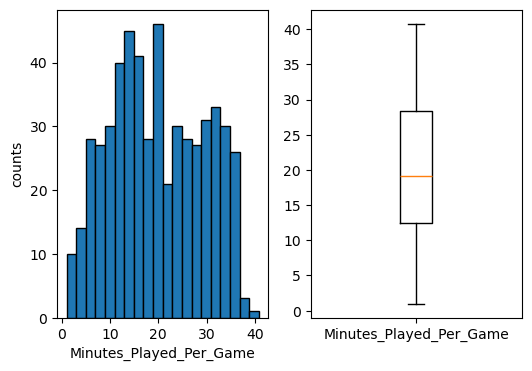

In [84]:
fig, ax = plt.subplots(1, 2, figsize=(6, 4))
ax = ax.flatten()
ax[0].hist(data['Minutes_Played_Per_Game'], bins=20, edgecolor='k')
ax[0].set_xlabel('Minutes_Played_Per_Game')
ax[0].set_ylabel('counts')

ax[1].boxplot(data['Minutes_Played_Per_Game'], labels=['Minutes_Played_Per_Game'])

plt.show()

In [85]:
df = data[data['Minutes_Played_Per_Game'] > 19].reset_index(drop=True)
df.shape

(275, 68)

In [86]:
df.replace({'Position': {'PG': 'G', 'SG': 'G', 'SF': 'F', 'PF': 'F'}}, inplace=True)

<Axes: xlabel='Position', ylabel='Count'>

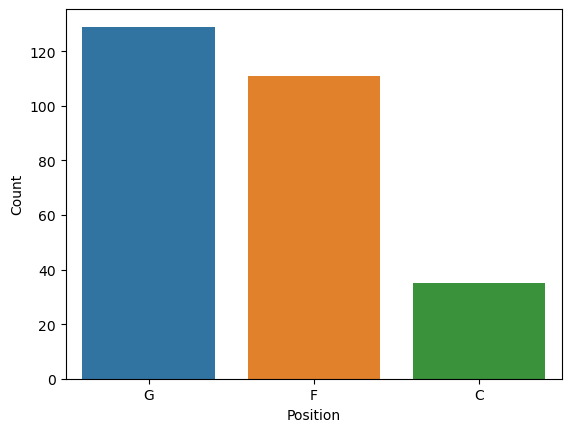

In [87]:
position_counts = df['Position'].value_counts().reset_index()
position_counts.columns = ['Position', 'Count']

sns.barplot(data=position_counts, x='Position', y='Count', hue='Position')

In [88]:
# position_counts = df['Position'].value_counts().reset_index()
# position_counts.columns = ['Position', 'Count']

# fig, ax = plt.subplots(1, 2, figsize=(12, 4))
# ax = ax.flatten()
# sns.histplot(data=df['Minutes_Played_Per_Game'], kde=True, bins=20, ax=ax[0], color='k', alpha=0.3)
# ax[0].set_xlabel("MPg")
# ax[0].set_ylabel("Count")

# sns.boxplot(data=df, x='Minutes_Played_Per_Game', y='Position', hue='Position', order=['G', 'F', 'C'], hue_order=['G', 'F', 'C'], ax=ax[1])
# ax[1].set_xlabel("MPg")
# ax[1].set_ylabel("Position")

# positions=['G', 'F', 'C']
# colors = {'G': None, 'F': 'orange', 'C': 'green'}

# positions = ['G', 'F', 'C']
# colors = {'G':'steelblue', 'F':'darkorange', 'C':'forestgreen'}
# fig, axes = plt.subplots(3, 1, figsize=(15, 10))  # 建立 3×1 子圖

# for idx, pos in enumerate(positions):
#     sub = df[df['Position'] == pos].sort_values(by='Minutes_Played_Per_Game', ascending=False).head(15)
#     sns.barplot(x='Player_Name', y='Minutes_Played_Per_Game', data=sub, ax=axes[idx], color=colors[pos])
#     axes[idx].set_title(f"Position: {pos} — Top 30 Players by MPg")
#     axes[idx].set_ylabel('MPg')
#     axes[idx].tick_params(axis='x', rotation=45)

# plt.tight_layout()
# plt.show()

## Offensive
[Offensive Overview](https://cleaningtheglass.com/stats/guide/player_offensive_overview)

Text(0, 0.5, 'Position')

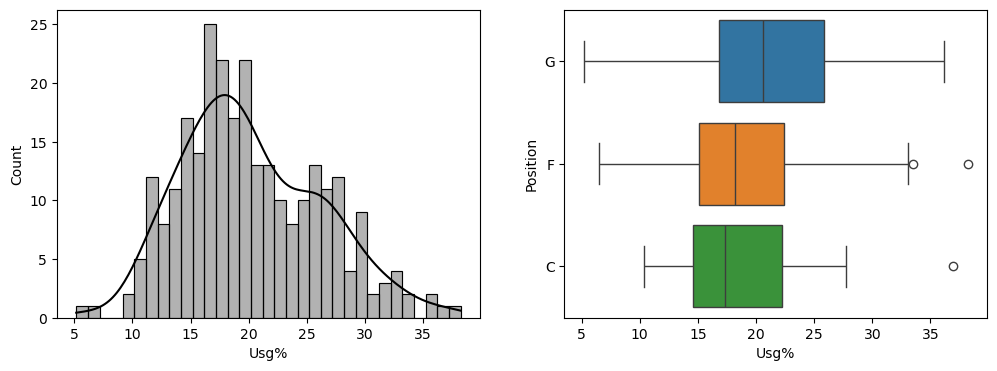

In [89]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax = ax.flatten()

sns.histplot(df['Usage_Percentage'], kde=True, binwidth=1, ax=ax[0], color='k', alpha=0.3)
ax[0].set_xlabel("Usg%")
ax[0].set_ylabel("Count")

sns.boxplot(data=df, x='Usage_Percentage', y='Position', hue='Position', order=['G', 'F', 'C'], hue_order=['G', 'F', 'C'], ax=ax[1])
ax[1].set_xlabel("Usg%")
ax[1].set_ylabel("Position")

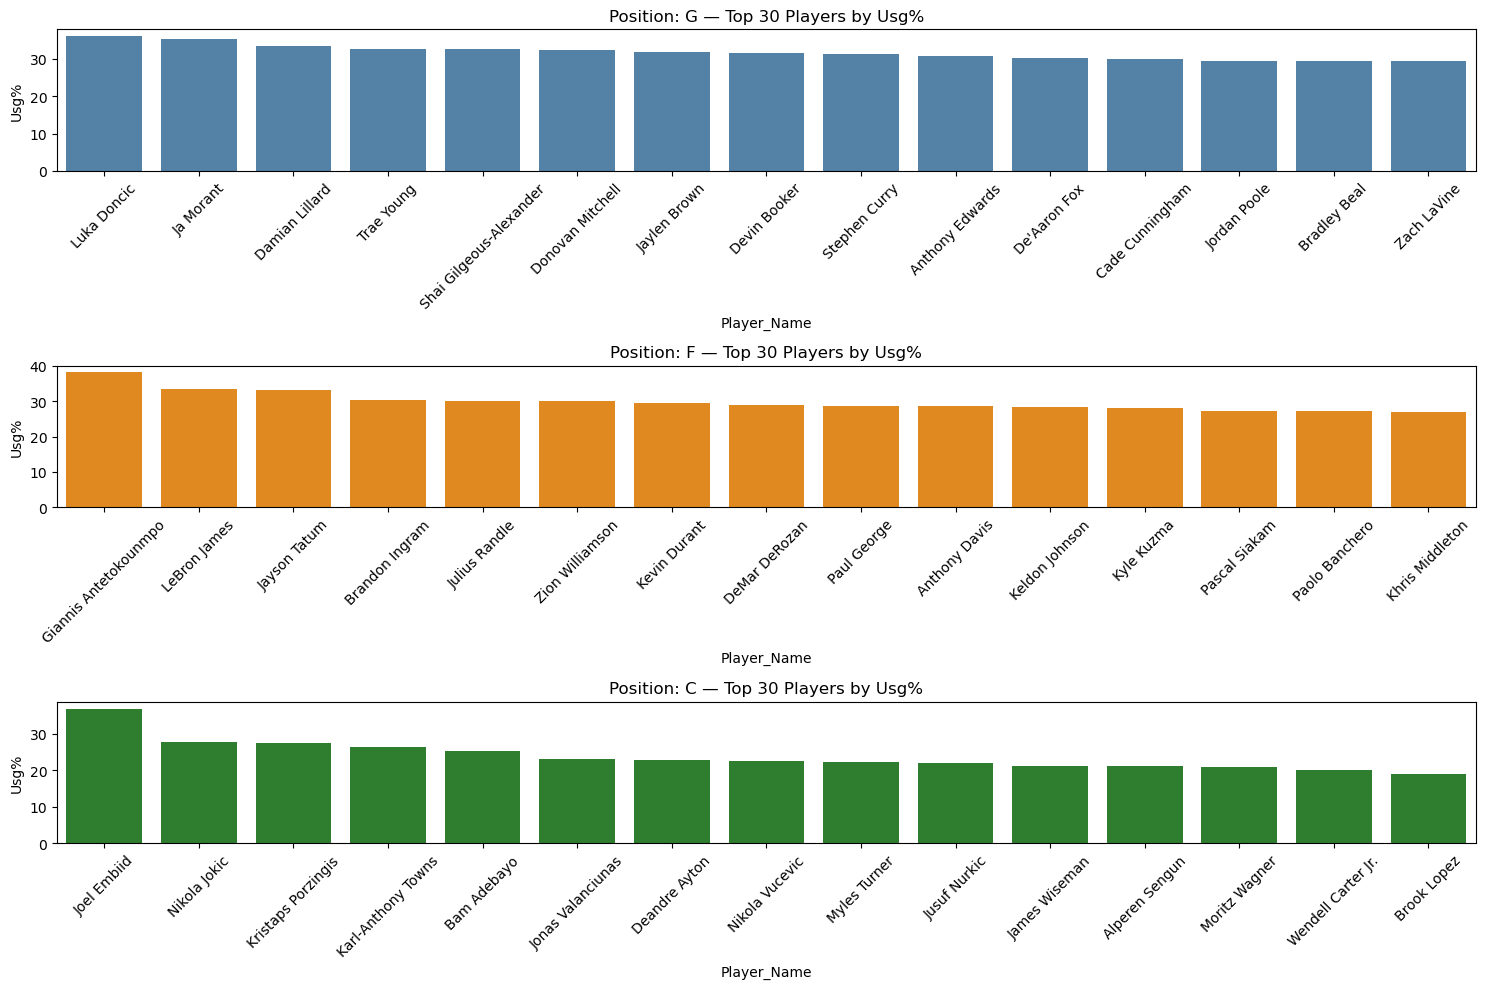

In [90]:
positions = ['G', 'F', 'C']
colors = {'G':'steelblue', 'F':'darkorange', 'C':'forestgreen'}
fig, axes = plt.subplots(3, 1, figsize=(15, 10))  # 建立 3×1 子圖

for idx, pos in enumerate(positions):
    sub = df[df['Position'] == pos].sort_values(by='Usage_Percentage', ascending=False).head(15)
    sns.barplot(x='Player_Name', y='Usage_Percentage', data=sub, ax=axes[idx], color=colors[pos])
    axes[idx].set_title(f"Position: {pos} — Top 30 Players by Usg%")
    axes[idx].set_ylabel('Usg%')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

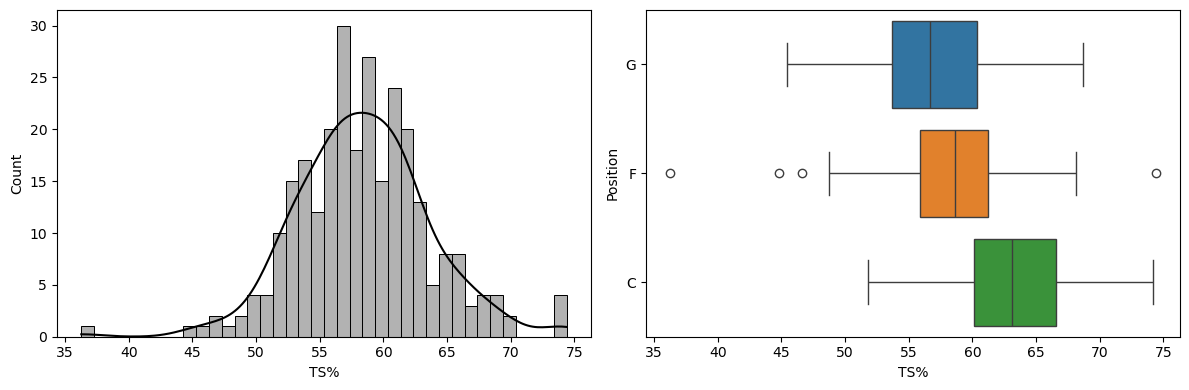

In [91]:
position_counts = df['Position'].value_counts().reset_index()
position_counts.columns = ['Position', 'Count']

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax = ax.flatten()

sns.histplot(df['True_Shooting_Percentage'], kde=True, binwidth=1, ax=ax[0], color='k', alpha=0.3)
ax[0].set_xlabel("TS%")
ax[0].set_ylabel("Count")

sns.boxplot(data=df, x='True_Shooting_Percentage', y='Position', hue='Position', order=['G', 'F', 'C'], hue_order=['G', 'F', 'C'], ax=ax[1])
ax[1].set_xlabel("TS%")
ax[1].set_ylabel("Position")

plt.tight_layout()
plt.show()

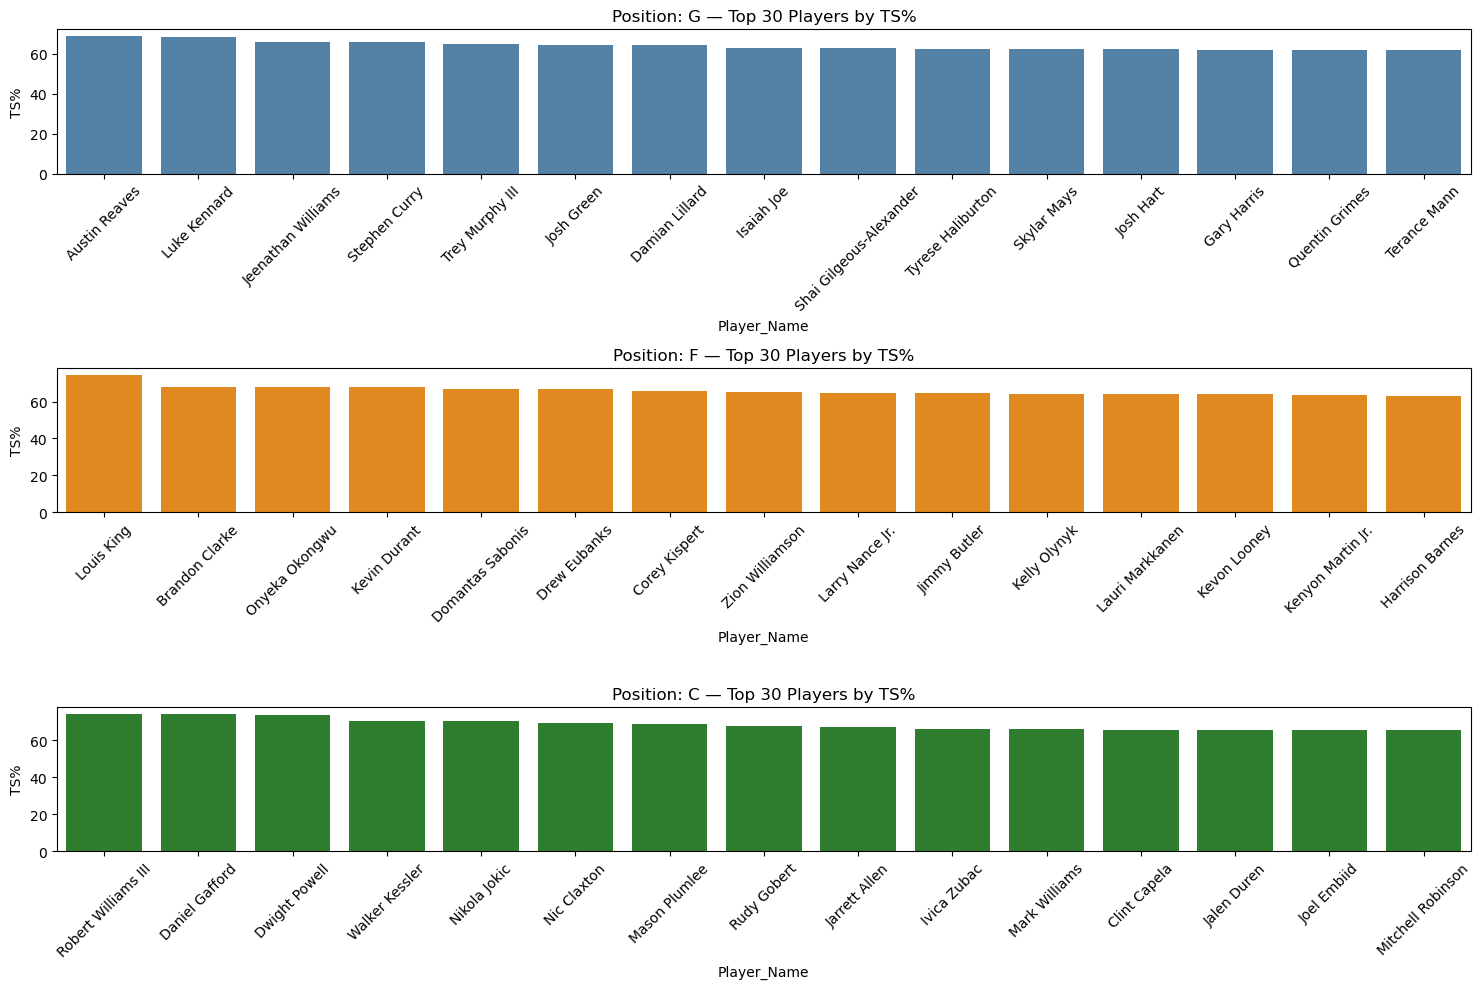

In [92]:
positions = ['G', 'F', 'C']
colors = {'G':'steelblue', 'F':'darkorange', 'C':'forestgreen'}
fig, axes = plt.subplots(3, 1, figsize=(15, 10))  # 建立 3×1 子圖

for idx, pos in enumerate(positions):
    sub = df[df['Position'] == pos].sort_values(by='True_Shooting_Percentage', ascending=False).head(15)
    sns.barplot(x='Player_Name', y='True_Shooting_Percentage', data=sub, ax=axes[idx], color=colors[pos])
    axes[idx].set_title(f"Position: {pos} — Top 30 Players by TS%")
    axes[idx].set_ylabel('TS%')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [93]:
Offensive_df = df[['Player_Name', 'Position', 'Points_Per_Game', 'Field_Goal_Attempted_Per_Game', 'True_Shooting_Percentage', 'Effective_Field_Goal_Percentage', 'Usage_Percentage', 'Turnovers_Percentage', 'Assists_Percentage',
                   'Assists_Per_Game', 'Turnovers_Per_Game', 'Offensive_Rebounds_Per_Game', 'Offensive_Rebounds_Percentage',
                   'Three_Point_Attempted_Per_Game', 'Three_Point_Percentage', 'Two_Point_Attempted_Per_Game', 'Two_Point_Percentage', 'Free_Throw_Attempted_Per_Game', 'Free_Throw_Percentage', 'Salary']]
Offensive_df.rename(columns={'Points_Per_Game':'PPg', 'Field_Goal_Attempted_Per_Game':'FGAg', 'Three_Point_Attempted_Per_Game':'3PAg',
                             'Two_Point_Attempted_Per_Game':'2PAg', 'Free_Throw_Attempted_Per_Game':"FTAg",
                             'Free_Throw_Percentage':'FT%','Three_Point_Percentage':'3P%', 'Two_Point_Percentage':'2P%', 'Usage_Percentage':"USG%", 'Turnovers_Per_Game':'TOVg',
                             'Assists_Per_Game':"ASTg", 'True_Shooting_Percentage':'TS%', 'Turnovers_Percentage':'TOV%', 'Assists_Percentage':'AST%',
                             'Effective_Field_Goal_Percentage':'eFG%', 'Offensive_Rebounds_Per_Game':'ORg', 'Offensive_Rebounds_Percentage':'OR%'}, inplace=True)
# plt.figure(figsize=(10, 10))
# sns.pairplot(Offensive_df, hue='Position', hue_order=['G', 'F', 'C'], height=1.5)
# plt.tight_layout()
# plt.show()

C:\Users\No\AppData\Local\Temp\ipykernel_22348\3433574560.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Offensive_df.rename(columns={'Points_Per_Game':'PPg', 'Field_Goal_Attempted_Per_Game':'FGAg', 'Three_Point_Attempted_Per_Game':'3PAg',


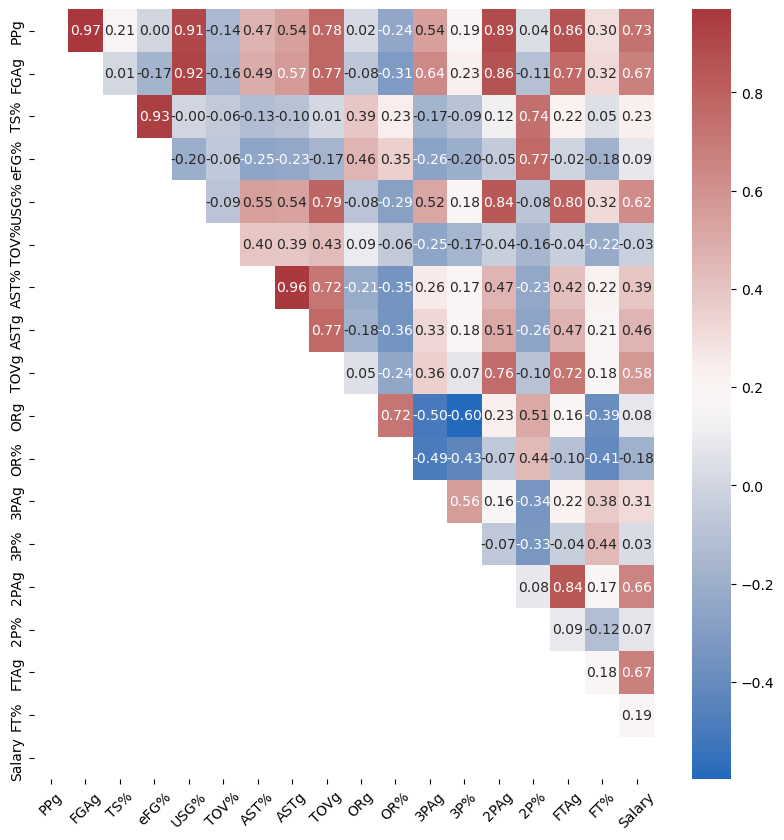

In [94]:
corr_matrix = Offensive_df.drop(columns=['Player_Name', 'Position']).corr()
mask = np.tril(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 10))
sns.heatmap(data=corr_matrix, mask=mask,fmt='.2f', annot=True, cmap='vlag')
plt.xticks(rotation=45)
plt.show()

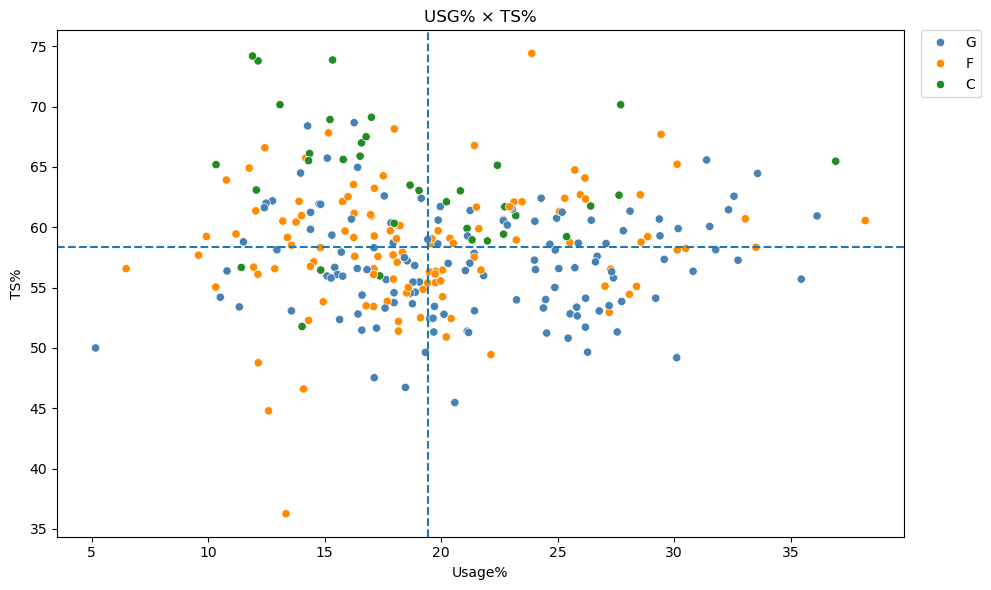

In [95]:
class_offecfive_df = Offensive_df.copy()

USG_median = class_offecfive_df['USG%'].median()
TS_mean = class_offecfive_df['TS%'].mean()

class_offecfive_df['USG_class'] = np.where(class_offecfive_df['USG%']>=USG_median, 'High_USG', 'Low_USG')
class_offecfive_df['TS_class'] = np.where(class_offecfive_df['TS%']>=TS_mean, 'High_TS', 'Low_TS')

class_offecfive_df['Quadrant'] = (class_offecfive_df['USG_class']+' & '+class_offecfive_df['TS_class'])

colors = {'G':'steelblue', 'F':'darkorange', 'C':'forestgreen'}

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=class_offecfive_df, x='USG%', y='TS%', hue='Position', hue_order=['G', 'F', 'C'], palette=colors)
ax.axvline(USG_median, ls='--')
ax.axhline(TS_mean,  ls='--')
ax.set_xlabel('Usage%')
ax.set_ylabel('TS%')
ax.set_title('USG% × TS%')
ax.legend(bbox_to_anchor=(1.02, 1),    # 右上角外偏
          loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

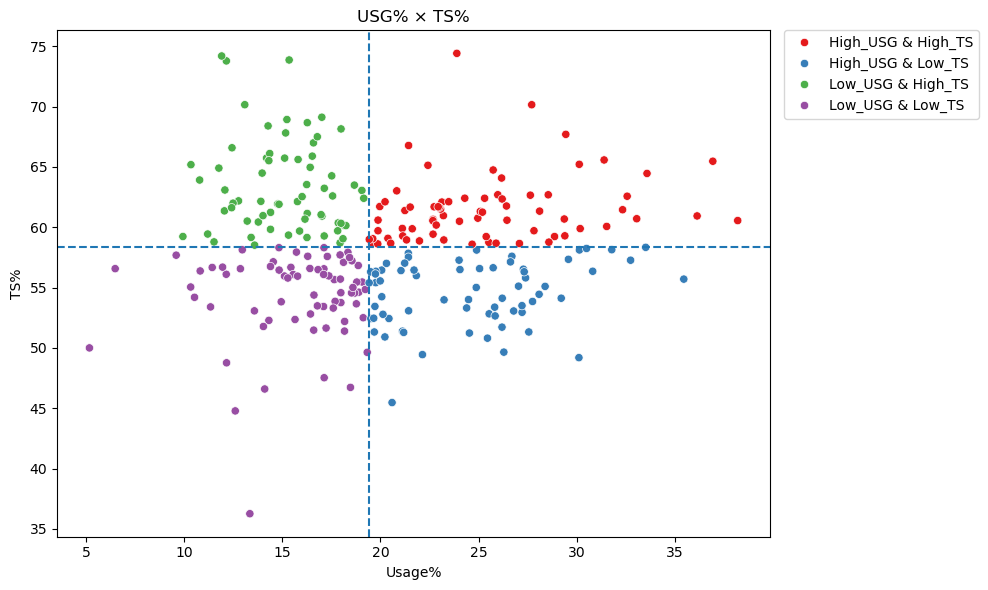

In [96]:
class_offecfive_df = Offensive_df.copy()

USG_median = class_offecfive_df['USG%'].median()
TS_mean = class_offecfive_df['TS%'].mean()

class_offecfive_df['USG_class'] = np.where(class_offecfive_df['USG%']>=USG_median, 'High_USG', 'Low_USG')
class_offecfive_df['TS_class'] = np.where(class_offecfive_df['TS%']>=TS_mean, 'High_TS', 'Low_TS')

class_offecfive_df['Quadrant'] = (class_offecfive_df['USG_class']+' & '+class_offecfive_df['TS_class'])

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=class_offecfive_df, x='USG%', y='TS%', hue='Quadrant', palette='Set1')
ax.axvline(USG_median, ls='--')
ax.axhline(TS_mean,  ls='--')
ax.set_xlabel('Usage%')
ax.set_ylabel('TS%')
ax.set_title('USG% × TS%')
ax.legend(bbox_to_anchor=(1.02, 1),    # 右上角外偏
          loc='upper left', borderaxespad=0.)
plt.tight_layout()
plt.show()

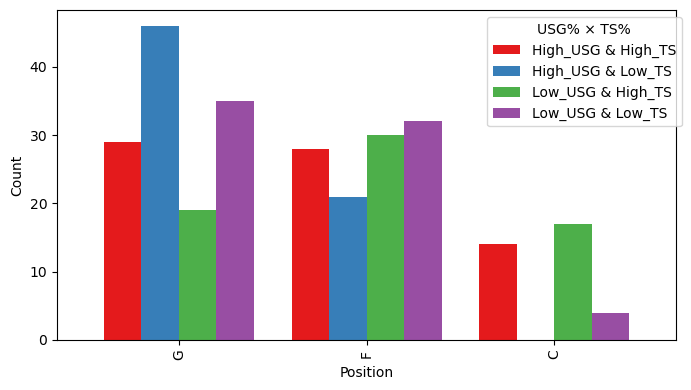

In [97]:
colors = ['#e41a1c', '#377eb8', '#4daf4a', '#984ea3'] 
table = pd.crosstab(class_offecfive_df['Position'], 
                    class_offecfive_df['Quadrant']).reindex(['G','F','C'])

table[['High_USG & High_TS','High_USG & Low_TS',
       'Low_USG & High_TS','Low_USG & Low_TS']].plot(kind='bar', figsize=(7,4), width=0.8, color=colors)

plt.ylabel('Count')
plt.xlabel('Position')
plt.legend(title='USG% × TS%', bbox_to_anchor=(1.02,1))
plt.tight_layout()
plt.show()

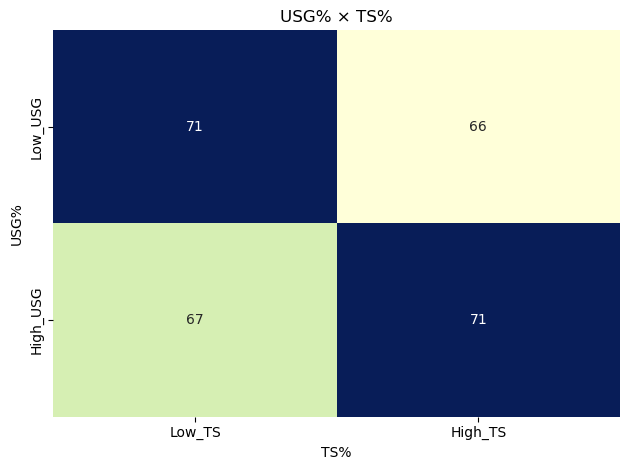

In [98]:
table_2x2 = pd.crosstab(class_offecfive_df['USG_class'],
                        class_offecfive_df['TS_class'],margins=False).reindex(index=['Low_USG', 'High_USG'], 
                                                                              columns=['Low_TS', 'High_TS'])

sns.heatmap(table_2x2, annot=True, cmap='YlGnBu', fmt='g', cbar=False)

plt.xlabel('TS%')
plt.ylabel('USG%')
plt.title('USG% × TS%')
plt.tight_layout()
plt.show()


In [99]:
class_offecfive_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 275 entries, 0 to 274
Data columns (total 23 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Player_Name  275 non-null    object 
 1   Position     275 non-null    object 
 2   PPg          275 non-null    float64
 3   FGAg         275 non-null    float64
 4   TS%          275 non-null    float64
 5   eFG%         275 non-null    float64
 6   USG%         275 non-null    float64
 7   TOV%         275 non-null    float64
 8   AST%         275 non-null    float64
 9   ASTg         275 non-null    float64
 10  TOVg         275 non-null    float64
 11  ORg          275 non-null    float64
 12  OR%          275 non-null    float64
 13  3PAg         275 non-null    float64
 14  3P%          275 non-null    float64
 15  2PAg         275 non-null    float64
 16  2P%          275 non-null    float64
 17  FTAg         275 non-null    float64
 18  FT%          275 non-null    float64
 19  Salary  

In [100]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree

X = class_offecfive_df.drop(columns=['Player_Name', 'USG_class', 'TS_class', 'Quadrant', 'USG%', 'TS%', 'Salary'])
y = class_offecfive_df['Quadrant']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

num_cols = ['PPg', 'FGAg', 'ASTg', 'TOVg', '3PAg', '3P%', '2PAg', '2P%', 'FTAg', 'FT%',
            'eFG%', 'TOV%', 'AST%', 'ORg', 'OR%']
cat_cols  = ['Position']

preprocessor = ColumnTransformer(transformers=[('num', StandardScaler(), num_cols),
                                               ('cat', OneHotEncoder(drop='first'), cat_cols)])

In [101]:
lrc = Pipeline(steps=[('prep', preprocessor), 
                             ('lrc',  LogisticRegression(max_iter=100, multi_class='multinomial', random_state=42))])

lrc.fit(X_train, y_train)
y_pred_lrc = lrc.predict(X_test)

print("=== Logistic Regression ===")
print(classification_report(y_test, y_pred_lrc))

=== Logistic Regression ===
                    precision    recall  f1-score   support

High_USG & High_TS       0.90      0.82      0.86        22
 High_USG & Low_TS       0.83      0.75      0.79        20
 Low_USG & High_TS       0.86      0.90      0.88        20
  Low_USG & Low_TS       0.75      0.86      0.80        21

          accuracy                           0.83        83
         macro avg       0.84      0.83      0.83        83
      weighted avg       0.84      0.83      0.83        83



c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [102]:
rfc = Pipeline(steps=[('prep', preprocessor),('rfc',  RandomForestClassifier(n_estimators=300, 
                                                                             max_depth=None, 
                                                                             class_weight='balanced',
                                                                             random_state=42))])
rfc.fit(X_train, y_train)
y_pred_rf = rfc.predict(X_test)

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf))

=== Random Forest ===
                    precision    recall  f1-score   support

High_USG & High_TS       0.89      0.73      0.80        22
 High_USG & Low_TS       0.79      0.75      0.77        20
 Low_USG & High_TS       0.82      0.90      0.86        20
  Low_USG & Low_TS       0.75      0.86      0.80        21

          accuracy                           0.81        83
         macro avg       0.81      0.81      0.81        83
      weighted avg       0.81      0.81      0.81        83



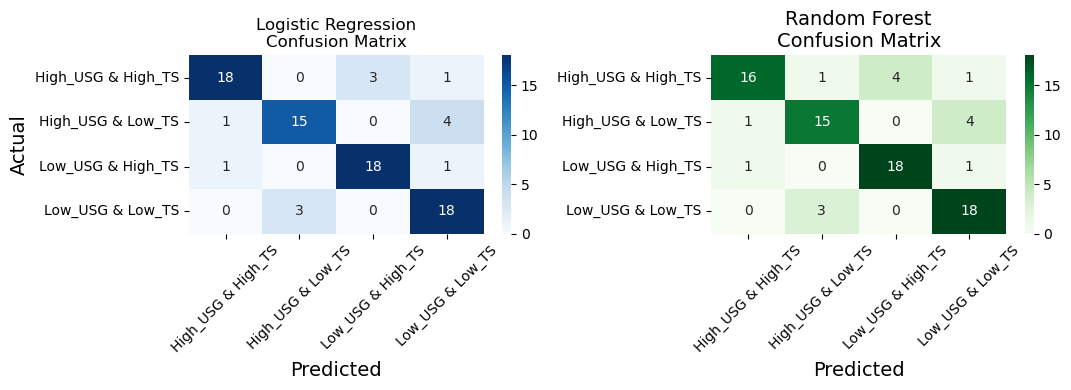

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(11,4))

cm_lrc = confusion_matrix(y_test, y_pred_lrc, labels=lrc.classes_)
sns.heatmap(cm_lrc, annot=True, fmt='d', cmap='Blues',
            xticklabels=lrc.classes_, yticklabels=lrc.classes_, ax=axes[0])
axes[0].set_title('Logistic Regression\nConfusion Matrix')
axes[0].set_xlabel('Predicted', fontsize=14)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
axes[0].set_ylabel('Actual', fontsize=14)

cm_rf = confusion_matrix(y_test, y_pred_rf, labels=rfc.classes_)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=rfc.classes_, yticklabels=rfc.classes_, ax=axes[1])
axes[1].set_title('Random Forest\nConfusion Matrix', fontsize=14)
axes[1].set_xlabel('Predicted', fontsize=14)
axes[1].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
axes[1].set_ylabel('')

plt.tight_layout(); plt.show()

In [104]:
results_lrc = pd.DataFrame({'Actual':y_test, 'Predicted': y_pred_lrc}, index=y_test.index)

mis_idx = results_lrc.index[results_lrc['Actual'] != results_lrc['Predicted']]

aux_cols = ['Player_Name', 'Position']
aux_info = data.loc[mis_idx, aux_cols]

mis_results_lrc_df = (pd.concat([aux_info, results_lrc.loc[mis_idx]], axis=1).reset_index(drop=True))

results_rf = pd.DataFrame({'Actual':y_test, 'Predicted': y_pred_rf}, index=y_test.index)

mis_idx = results_rf.index[results_rf['Actual'] != results_rf['Predicted']]

aux_cols = ['Player_Name', 'Position']
aux_info = data.loc[mis_idx, aux_cols]

mis_results_rf_df = (pd.concat([aux_info, results_rf.loc[mis_idx]], axis=1).reset_index(drop=True))

the_same = pd.merge(mis_results_lrc_df, mis_results_rf_df)

print(f"Logistic Regression 共有 {len(mis_results_lrc_df)} 筆分類錯誤：\n")
print(mis_results_lrc_df,'\n')
print('-------------------------------------------------------')
print(f"Random Forest 共有 {len(mis_results_rf_df)} 筆分類錯誤：\n")
print(mis_results_rf_df,'\n')
print('-------------------------------------------------------')
print(f'都被分錯的球員是: \n')
print(the_same['Player_Name'])

Logistic Regression 共有 14 筆分類錯誤：

         Player_Name Position              Actual           Predicted
0    Cameron Johnson       SF  High_USG & High_TS   Low_USG & High_TS
1    Andrew Nembhard       PG   High_USG & Low_TS    Low_USG & Low_TS
2      Dwight Powell        C  High_USG & High_TS    Low_USG & Low_TS
3    Dennis Schroder       PG    Low_USG & Low_TS   High_USG & Low_TS
4      Tobias Harris       PF   Low_USG & High_TS  High_USG & High_TS
5      Nick Richards        C  High_USG & High_TS   Low_USG & High_TS
6   Jabari Smith Jr.       PF    Low_USG & Low_TS   High_USG & Low_TS
7       Caris LeVert       SG    Low_USG & Low_TS   High_USG & Low_TS
8         Cam Thomas       SG  High_USG & High_TS   Low_USG & High_TS
9    Josh Richardson       SG   High_USG & Low_TS    Low_USG & Low_TS
10  Donte DiVincenzo       SG   High_USG & Low_TS    Low_USG & Low_TS
11      Bobby Portis        F   High_USG & Low_TS  High_USG & High_TS
12     Jeremy Sochan        F   Low_USG & High_TS    Low

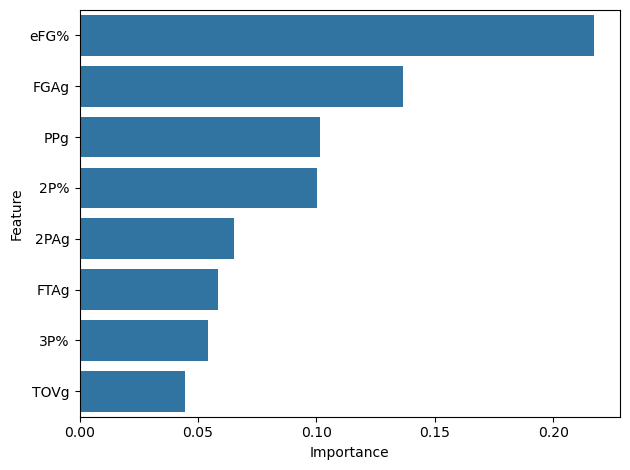

In [105]:
rf_model = rfc.named_steps['rfc']

importances = rf_model.feature_importances_

feature_names_num = preprocessor.named_transformers_['num'].get_feature_names_out(num_cols)
feature_names_cat = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols)

# 合併
feature_names = np.concatenate([feature_names_num, feature_names_cat])

importance_df = (pd.DataFrame({'Feature': feature_names,
                               'Importance': importances}).sort_values('Importance', ascending=False).reset_index(drop=True))


sns.barplot(data=importance_df.head(8), x='Importance', y='Feature')
plt.tight_layout()
plt.show()


In [106]:
first_tree = rf_model.estimators_[0] # 取第0棵

feature_names = list(feature_names_num) + list(feature_names_cat)

# plt.figure(figsize=(22, 12), dpi=120)
# plot_tree(first_tree, feature_names=feature_names, class_names=rf_model.classes_.tolist(), 
#           filled=True, rounded=True, max_depth=3, fontsize=10) # 若想全深度可移除, 最深到8
# plt.tight_layout()
# plt.show()


In [107]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [108]:
Offensive_df.drop(columns=['Player_Name', 'Position', 'Salary'])

,PPg,FGAg,TS%,eFG%,USG%,TOV%,AST%,ASTg,TOVg,ORg,OR%,3PAg,3P%,2PAg,2P%,FTAg,FT%
0,30.067568,21.067568,60.703451,54.329699,33.060489,10.412186,21.019590,4.621622,2.878378,1.054054,0.120185,9.270270,35.0,11.797297,55.784651,8.405405,85.4
1,33.075758,20.121212,65.467479,57.304217,36.939470,11.937208,22.687995,4.151515,3.424242,1.712121,0.168657,3.030303,33.0,17.090909,58.687943,11.681818,85.7
2,32.393939,21.954545,60.933902,56.004141,36.139285,11.857151,38.693547,8.015152,3.575758,0.818182,0.094903,8.196970,34.2,13.757576,58.810573,10.515152,74.2
3,31.397059,20.308824,62.567403,53.077480,32.573588,10.115059,25.273725,5.455882,2.823529,0.867647,0.179331,2.470588,34.5,17.838235,53.256389,10.867647,90.5
4,31.095238,20.285714,60.549676,57.159624,38.208234,13.199691,31.730435,5.698413,3.904762,2.174603,0.184636,2.714286,27.5,17.571429,59.620596,12.253968,64.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
270,20.000000,13.000000,74.404762,76.923077,23.892132,12.953368,12.189997,2.000000,2.000000,2.000000,0.500000,8.000000,50.0,5.000000,80.000000,1.000000,0.0
271,4.250000,5.750000,36.262799,36.956522,13.342971,14.577259,5.821199,1.000000,1.000000,0.750000,0.200000,3.000000,25.0,2.750000,36.363636,0.250000,0.0
272,16.000000,12.000000,62.111801,58.333333,23.476913,23.696682,33.155026,7.000000,4.000000,3.000000,0.333333,5.000000,40.0,7.000000,57.142857,2.000000,100.0
273,7.000000,5.000000,51.775148,60.000000,14.033460,0.000000,0.000000,0.000000,0.000000,2.000000,0.666667,0.000000,0.0,5.000000,60.000000,4.000000,25.0


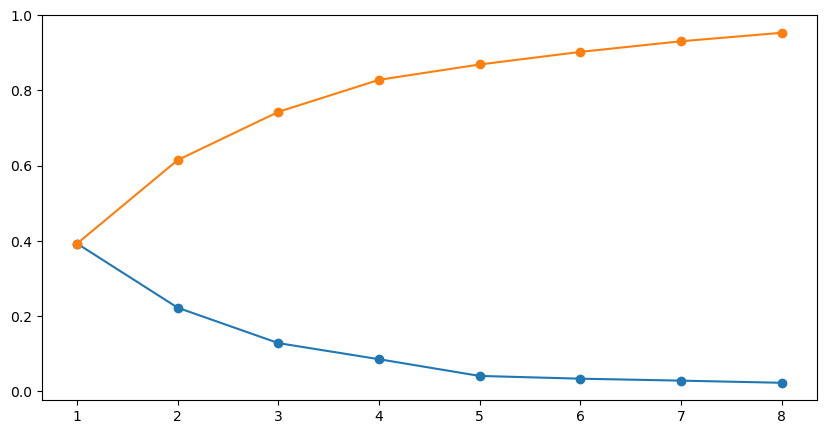

In [109]:
scaler = StandardScaler()
per_df_scaled = scaler.fit_transform(Offensive_df.drop(columns=['Player_Name', 'Position', 'Salary']))
pca = PCA(n_components=0.95)
x_pca = pca.fit_transform(per_df_scaled)
# pca_df = pd.DataFrame(data=x_pca, columns=['PC1', 'PC2'])

explained_variance = pca.explained_variance_ratio_
cum_explained_variance = np.cumsum(explained_variance)
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o', label='explined variance')
plt.plot(range(1, len(cum_explained_variance)+1), cum_explained_variance, marker='o', label='cumulative explained variance')
plt.show()

C:\Users\No\AppData\Local\Temp\ipykernel_22348\2777062695.py:7: UserWarning: The palette list has more values (4) than needed (3), which may not be intended.
  ax = sns.scatterplot(x=x_pca[:, 0], y=x_pca[:, 1], hue=class_offecfive_df['Position'], hue_order=positions, palette=colors)


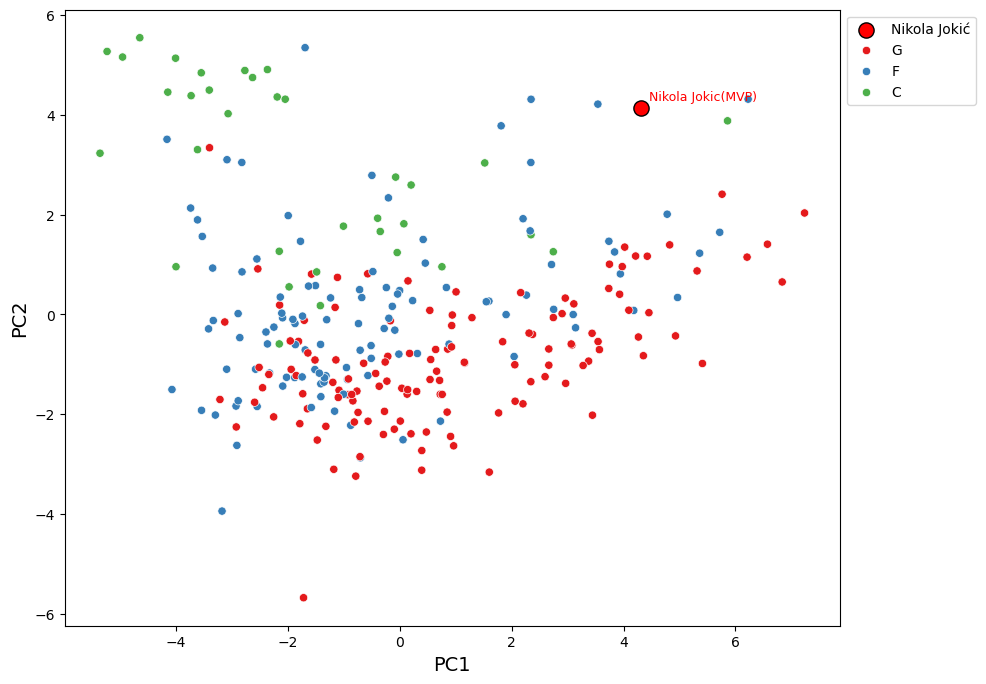

In [110]:
jokic_idx = data.index[data["Player_Name"] == "Nikola Jokic"]
xj, yj = x_pca[jokic_idx, 0], x_pca[jokic_idx, 1]

plt.figure(figsize=(10, 8))
plt.scatter(xj, yj, color="red", s=120, edgecolor="black", zorder=5, label="Nikola Jokić")
plt.text(xj + 0.15, yj + 0.15, "Nikola Jokic(MVP)", color="red", fontsize=9)
ax = sns.scatterplot(x=x_pca[:, 0], y=x_pca[:, 1], hue=class_offecfive_df['Position'], hue_order=positions, palette=colors)
ax.legend(bbox_to_anchor=(1, 1), loc='upper left')
ax.set_xlabel('PC1', fontsize=14)
ax.set_ylabel('PC2', fontsize=14)
plt.show()

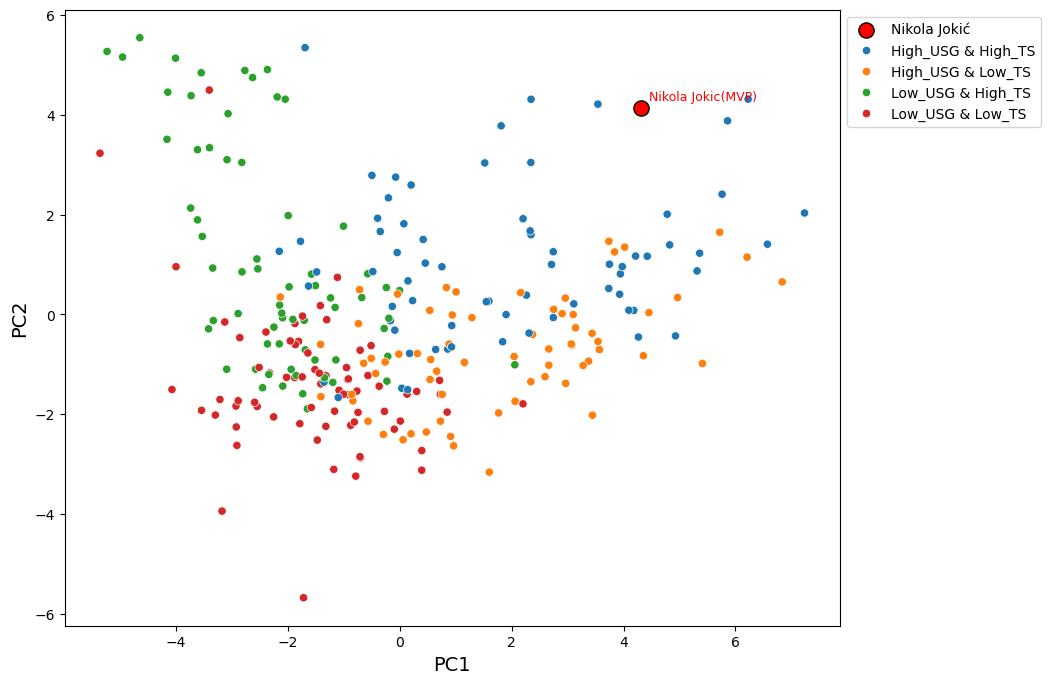

In [111]:
jokic_idx = data.index[data["Player_Name"] == "Nikola Jokic"]
xj, yj = x_pca[jokic_idx, 0], x_pca[jokic_idx, 1]

plt.figure(figsize=(10, 8))
plt.scatter(xj, yj, color="red", s=120, edgecolor="black", zorder=5, label="Nikola Jokić")
plt.text(xj + 0.15, yj + 0.15, "Nikola Jokic(MVP)", color="red", fontsize=9)
ax = sns.scatterplot(x=x_pca[:, 0], y=x_pca[:, 1], hue=class_offecfive_df['Quadrant'])
ax.legend(bbox_to_anchor=(1, 1), loc='upper left')
ax.set_xlabel('PC1', fontsize=14)
ax.set_ylabel('PC2', fontsize=14)
plt.show()

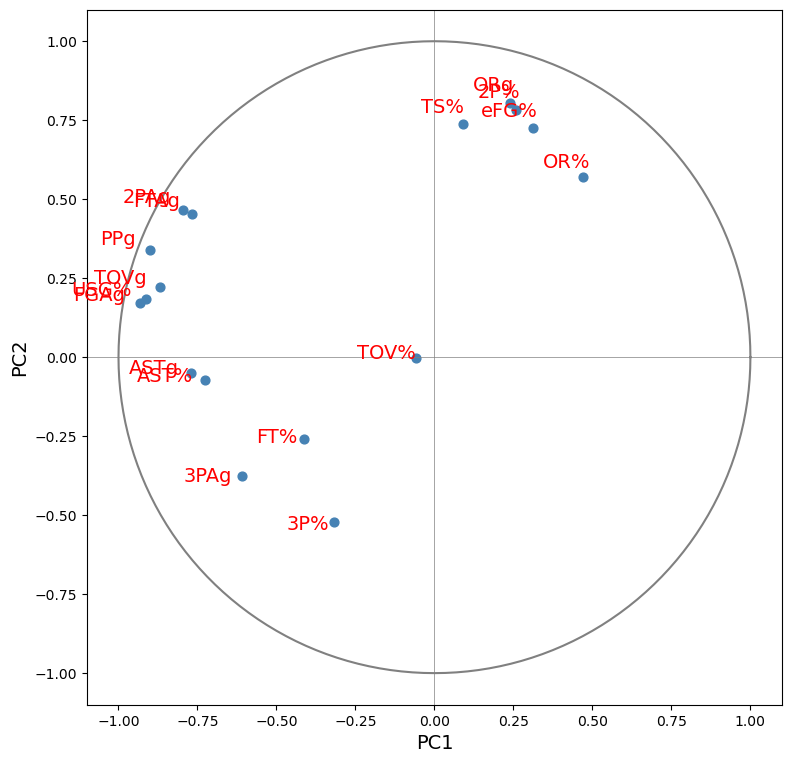

In [112]:
num_cols = Offensive_df.drop(columns=['Player_Name', 'Position', 'Salary']).columns
X_std = StandardScaler().fit_transform(Offensive_df[num_cols])

n, p = X_std.shape

cov_mat = np.cov(X_std.T, bias=False)
eigen_val, eigen_vec = np.linalg.eigh(cov_mat)

idx_sorted = np.argsort(eigen_val)[::-1]
lamda_ = eigen_val[idx_sorted][:2]
vector_ = eigen_vec[:, idx_sorted][:, :2]

corr = vector_ * np.sqrt(lamda_) 

theta = np.linspace(0, 2*np.pi, 361)
ucircle = np.c_[np.cos(theta), np.sin(theta)]

fig, ax = plt.subplots(figsize=(8, 8))

ax.plot(ucircle[:,0], ucircle[:,1], color='grey')
ax.axhline(0, color='grey', lw=0.5)
ax.axvline(0, color='grey', lw=0.5)

for i, col in enumerate(num_cols):
    x, y = corr[i, 0], corr[i, 1]
    ax.scatter(x, y, color='steelblue', s=40)
    ax.text(x*1.05, y*1.05, col, fontsize=14,
            ha='right', va='baseline', color='red')

ax.set_xlabel(f'PC1', fontsize=14)
ax.set_ylabel(f'PC2', fontsize=14)
ax.set_xlim(-1.1, 1.1); ax.set_ylim(-1.1, 1.1)
ax.set_aspect('equal', 'box')

plt.tight_layout()
plt.show()


In [113]:
X

,Position,PPg,FGAg,eFG%,TOV%,AST%,ASTg,TOVg,ORg,OR%,3PAg,3P%,2PAg,2P%,FTAg,FT%
0,F,30.067568,21.067568,54.329699,10.412186,21.019590,4.621622,2.878378,1.054054,0.120185,9.270270,35.0,11.797297,55.784651,8.405405,85.4
1,C,33.075758,20.121212,57.304217,11.937208,22.687995,4.151515,3.424242,1.712121,0.168657,3.030303,33.0,17.090909,58.687943,11.681818,85.7
2,G,32.393939,21.954545,56.004141,11.857151,38.693547,8.015152,3.575758,0.818182,0.094903,8.196970,34.2,13.757576,58.810573,10.515152,74.2
3,G,31.397059,20.308824,53.077480,10.115059,25.273725,5.455882,2.823529,0.867647,0.179331,2.470588,34.5,17.838235,53.256389,10.867647,90.5
4,F,31.095238,20.285714,57.159624,13.199691,31.730435,5.698413,3.904762,2.174603,0.184636,2.714286,27.5,17.571429,59.620596,12.253968,64.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
270,F,20.000000,13.000000,76.923077,12.953368,12.189997,2.000000,2.000000,2.000000,0.500000,8.000000,50.0,5.000000,80.000000,1.000000,0.0
271,F,4.250000,5.750000,36.956522,14.577259,5.821199,1.000000,1.000000,0.750000,0.200000,3.000000,25.0,2.750000,36.363636,0.250000,0.0
272,F,16.000000,12.000000,58.333333,23.696682,33.155026,7.000000,4.000000,3.000000,0.333333,5.000000,40.0,7.000000,57.142857,2.000000,100.0
273,C,7.000000,5.000000,60.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.666667,0.000000,0.0,5.000000,60.000000,4.000000,25.0


In [116]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score


num_cols = ['PPg', 'FGAg', 'eFG%', 'TOV%', 'AST%', 'ASTg', 'TOVg', 'ORg', 'OR%', '3PAg', '3P%',
            '2PAg', '2P%', 'FTAg', 'FT%',]

cat_cols = ['Position']

preprocess = ColumnTransformer(transformers=[('num', StandardScaler(), num_cols),
                                             ('cat', OneHotEncoder(drop='first'), cat_cols)], 
                                             remainder='drop')

X = class_offecfive_df[num_cols + cat_cols]
y = np.log(class_offecfive_df['Salary'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=class_offecfive_df['Position'])

lin_reg = Pipeline(steps=[('prep',  preprocess), ('model', LinearRegression())])

lin_reg.fit(X_train, y_train)

y_pred_log = lin_reg.predict(X_test)
y_pred = np.exp(y_pred_log)           
y_true = np.exp(y_test)

mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)
print(f"Test MAE : ${mae:,.0f}")
print(f"Test R² : {r2:.2f}")

coef = lin_reg.named_steps['model'].coef_

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coef': pd.to_numeric(coef, errors='coerce')
}).sort_values(by='Coef', key=lambda x: x.abs(), ascending=False)

print(coef_df.head(10))

class_offecfive_df['Predicted_Salary'] = np.exp(lin_reg.predict(X))
print(class_offecfive_df[['Player_Name', 'Position', 'Salary', 'Predicted_Salary']].head())


Test MAE : $6,268,564
Test R² : 0.41
       Feature      Coef
0          PPg  0.420533
2         ASTg  0.310036
12        AST% -0.265526
7          2P%  0.199481
5          3P%  0.166885
15  Position_F  0.153843
10        eFG% -0.130549
14         OR%  0.127214
6         2PAg  0.113110
4         3PAg -0.099765
               Player_Name Position      Salary  Predicted_Salary
0             Jayson Tatum        F  32600060.0      4.375747e+07
1              Joel Embiid        C  53320232.0      4.646020e+07
2              Luka Doncic        G  43031940.0      4.574654e+07
3  Shai Gilgeous-Alexander        G  35859950.0      3.577628e+07
4    Giannis Antetokounmpo        F  45640084.0      4.756320e+07


In [ ]:
class_offecfive_df

,Player_Name,Position,PPg,FGAg,TS%,eFG%,USG%,TOV%,AST%,ASTg,...,3P%,2PAg,2P%,FTAg,FT%,Salary,USG_class,TS_class,Quadrant,Predicted_Salary
0,Jayson Tatum,F,30.067568,21.067568,60.703451,54.329699,33.060489,10.412186,21.019590,4.621622,...,35.0,11.797297,55.784651,8.405405,85.4,32600060.0,High_USG,High_TS,High_USG & High_TS,2.408454e+07
1,Joel Embiid,C,33.075758,20.121212,65.467479,57.304217,36.939470,11.937208,22.687995,4.151515,...,33.0,17.090909,58.687943,11.681818,85.7,53320232.0,High_USG,High_TS,High_USG & High_TS,8.136856e+07
2,Luka Doncic,G,32.393939,21.954545,60.933902,56.004141,36.139285,11.857151,38.693547,8.015152,...,34.2,13.757576,58.810573,10.515152,74.2,43031940.0,High_USG,High_TS,High_USG & High_TS,5.016908e+07
3,Shai Gilgeous-Alexander,G,31.397059,20.308824,62.567403,53.077480,32.573588,10.115059,25.273725,5.455882,...,34.5,17.838235,53.256389,10.867647,90.5,35859950.0,High_USG,High_TS,High_USG & High_TS,2.596992e+07
4,Giannis Antetokounmpo,F,31.095238,20.285714,60.549676,57.159624,38.208234,13.199691,31.730435,5.698413,...,27.5,17.571429,59.620596,12.253968,64.5,45640084.0,High_USG,High_TS,High_USG & High_TS,8.529689e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
270,Louis King,F,20.000000,13.000000,74.404762,76.923077,23.892132,12.953368,12.189997,2.000000,...,50.0,5.000000,80.000000,1.000000,0.0,5125000.0,High_USG,High_TS,High_USG & High_TS,3.767555e+06
271,Justin Minaya,F,4.250000,5.750000,36.262799,36.956522,13.342971,14.577259,5.821199,1.000000,...,25.0,2.750000,36.363636,0.250000,0.0,5125000.0,Low_USG,Low_TS,Low_USG & Low_TS,3.662547e+06
272,RaiQuan Gray,F,16.000000,12.000000,62.111801,58.333333,23.476913,23.696682,33.155026,7.000000,...,40.0,7.000000,57.142857,2.000000,100.0,5125000.0,High_USG,High_TS,High_USG & High_TS,5.327696e+06
273,Chance Comanche,C,7.000000,5.000000,51.775148,60.000000,14.033460,0.000000,0.000000,0.000000,...,0.0,5.000000,60.000000,4.000000,25.0,5125000.0,Low_USG,Low_TS,Low_USG & Low_TS,6.335858e+06


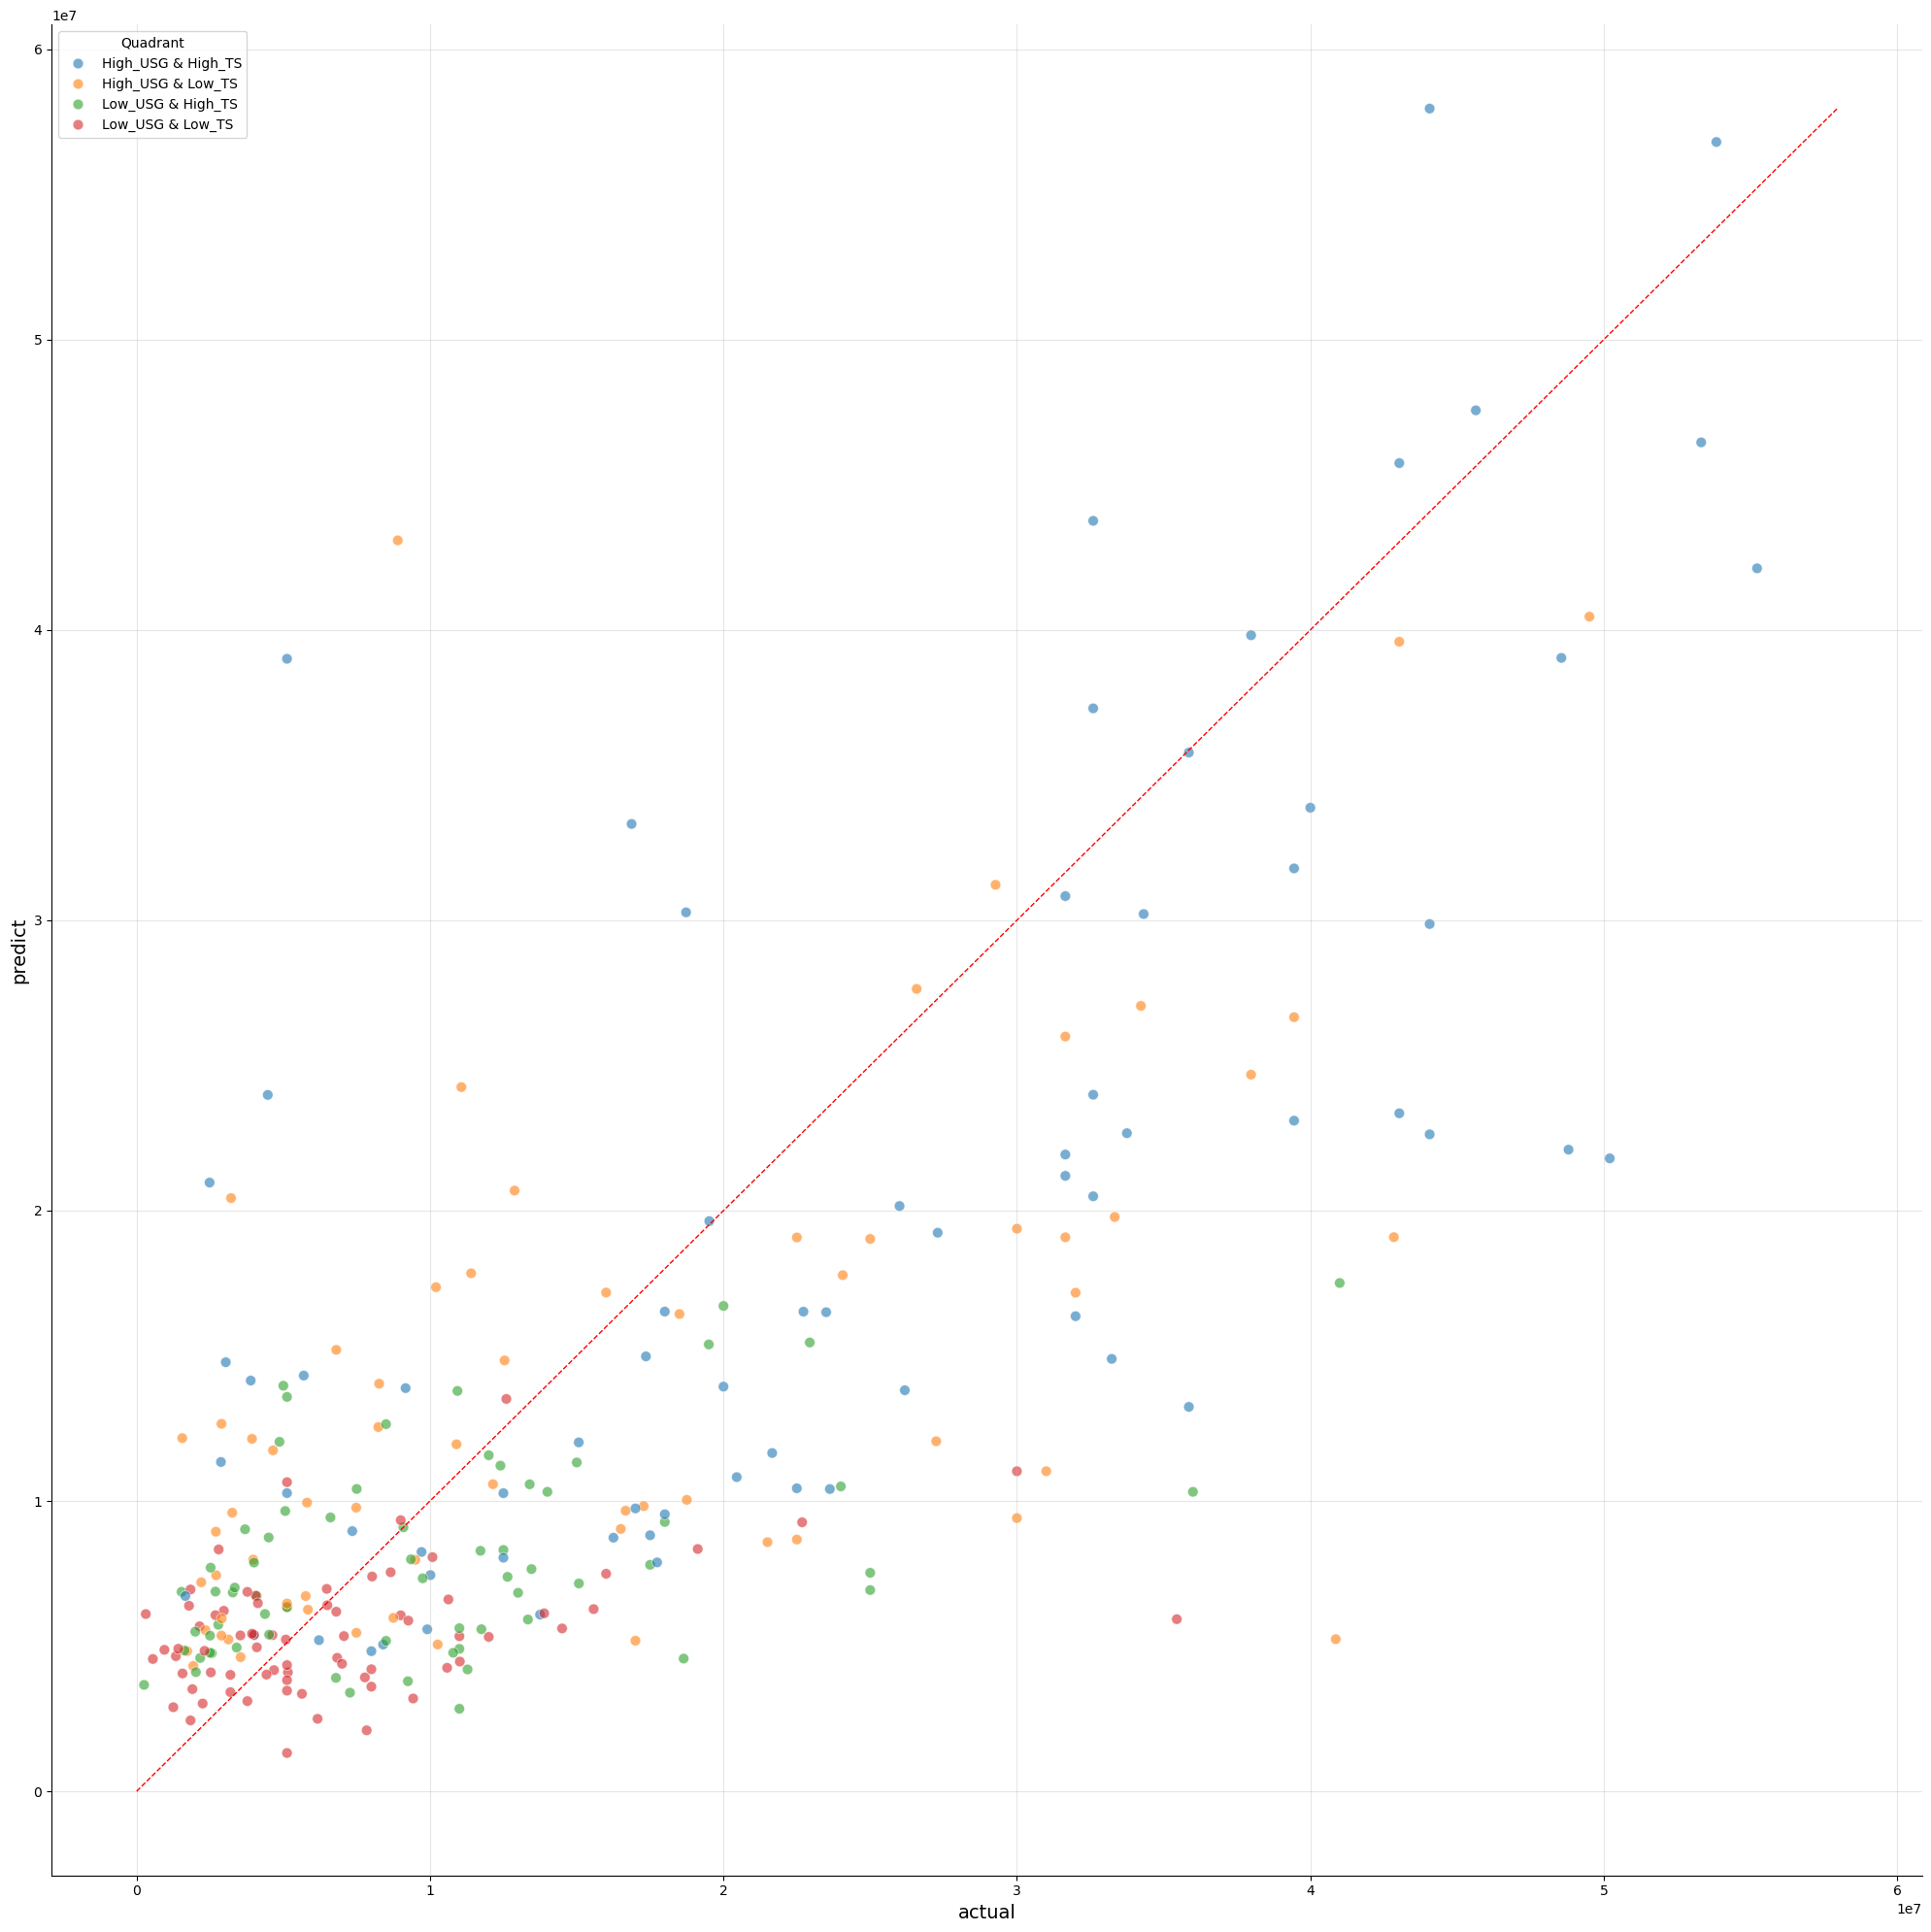

In [118]:
plt.figure(figsize=(20, 20))


sns.scatterplot(
    data=class_offecfive_df,
    x='Salary', y='Predicted_Salary',
    color='blue', alpha=0.6, s=60, hue=class_offecfive_df['Quadrant']) 

# 45 度參考線
max_val = max(class_offecfive_df['Salary'].max(), class_offecfive_df['Predicted_Salary'].max())
plt.plot([0, max_val], [0, max_val],
         ls='--', color='red', linewidth=1)

# 標題與座標軸
plt.xlabel('actual', fontsize=14)
plt.ylabel('predict', fontsize=14)

# 風格：等效於 theme_minimal()
sns.despine()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [119]:
# loadings = pd.DataFrame(
#     data=pca.components_.T,
#     columns=[f'PC{i+1}' for i in range(pca.n_components_)],
#     index=Offensive_df.drop(columns='Position').columns
# )

# plt.figure(figsize=(10, 5))
# loadings['PC1'].sort_values().plot(kind='barh', color='steelblue')
# plt.title('PCA Loading — PC1')
# plt.xlabel('Loading Value')
# plt.ylabel('Feature')
# plt.grid(True, axis='x', linestyle='--', alpha=0.5)
# plt.tight_layout()
# plt.show()

In [120]:
# plt.figure(figsize=(10, 5))
# loadings['PC2'].sort_values().plot(kind='barh', color='steelblue')
# plt.title('PCA Loading — PC2')
# plt.xlabel('Loading Value')
# plt.ylabel('Feature')
# plt.grid(True, axis='x', linestyle='--', alpha=0.5)
# plt.tight_layout()
# plt.show()
